# `oneuniverse.simulation` — the OUF-Sim store

Pillar 3 stores cosmological simulations in **OUF-Sim**, mirroring the OUF survey-database tech (JSON manifest + pyarrow parquet + HEALPix-NEST + memmap `.npy` tiles) with a sidecar `_index.parquet` per product for **partial-access** reads.

We use a *dummy linear simulation* (Eisenstein–Hu P(k) + Zel'dovich + toy halos + lightcone) as a stand-in for a real simulator — the focus is the **storage + access structure**, not real-sim application.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, json
from pathlib import Path
import tempfile
from oneuniverse.simulation.cosmology import CosmologySpec
from oneuniverse.simulation.linear import generate_linear_sim, linear_power
from oneuniverse.simulation.oufsim import write_oufsim_store, SimStore
from oneuniverse.simulation.selectors import Cube, Cone
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96,
                      sigma8=0.81, t_cmb=2.7255)
WORK = Path(tempfile.mkdtemp())
print('workdir', WORK)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


workdir /tmp/claude-1000/tmp0waxt_xo


## 1. Generate a dummy linear simulation
Pure numpy: E&H transfer → σ8-normalised P(k) → Gaussian field (FFT) → Zel'dovich particles → toy peak halos → toy HEALPix lightcone.

In [2]:
native = generate_linear_sim(WORK/'native', COSMO, box_size=256.0,
                              n_grid=64, redshifts=(0.0, 1.0), seed=2)
print('native products on disk:')
for p in sorted(Path(native).glob('*')): print(' ', p.name)
for p in sorted((Path(native)/'z0.000').glob('*')): print('   z0.000/', p.name)

native products on disk:
  checkpoint.json
  config.yaml
  ic_descriptor.json
  ic_field.npy
  lightcone.parquet
  tree.parquet
  z0.000
  z1.000
   z0.000/ amr.parquet
   z0.000/ field.npy
   z0.000/ gr_field.npy
   z0.000/ halos.parquet
   z0.000/ particles.npy
   z0.000/ phase_space.parquet


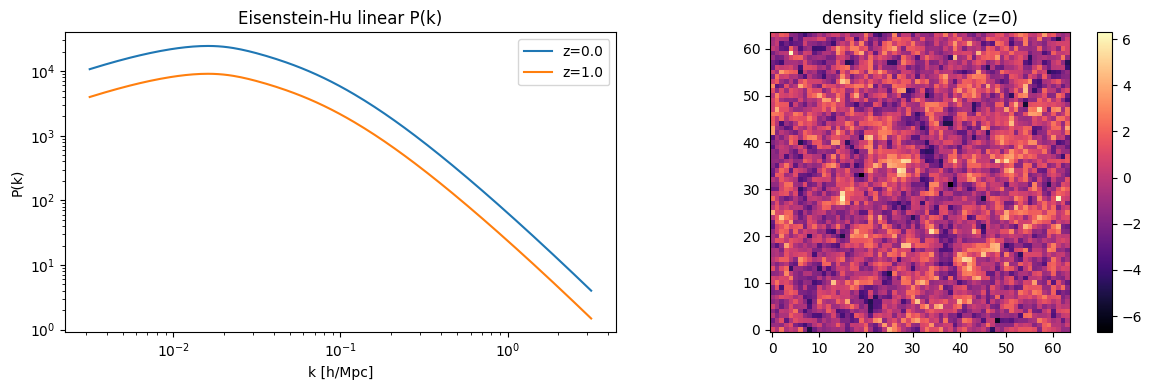

In [3]:
# the input physics: Eisenstein-Hu linear P(k)
k = np.logspace(-2.5, 0.5, 200)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for z in (0.0, 1.0):
    ax[0].loglog(k, linear_power(k, COSMO, z=z), label=f'z={z}')
ax[0].set_xlabel('k [h/Mpc]'); ax[0].set_ylabel('P(k)'); ax[0].legend()
ax[0].set_title('Eisenstein-Hu linear P(k)')
field = np.load(Path(native)/'z0.000'/'field.npy')
im = ax[1].imshow(field[:,:,32].T, origin='lower', cmap='magma')
ax[1].set_title('density field slice (z=0)'); plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

## 2. Convert to an OUF-Sim store
`write_oufsim_store` emits `manifest.json` + per-product parquet/tiles + sidecar indexes. **All 9 product kinds + AMR + input/output sides** are exercised by the dummy.

In [4]:
store = write_oufsim_store(native, WORK/'store', sim_name='demo')
man = json.load(open(store/'manifest.json'))
print('products:', man['products'])
print('store_layout keys:', list(man['store_layout'].keys()))
print('has_input:', man['has_input'], ' has_output:', man['has_output'])

products: ['snapshots', 'fields', 'halos', 'phase_space', 'gr_fields', 'ic_posterior', 'checkpoints', 'tree', 'lightcone']
store_layout keys: ['snapshots', 'fields', 'halos', 'phase_space', 'gr_fields', 'fields_amr', 'ic_posterior', 'checkpoints', 'tree', 'lightcone']
has_input: True  has_output: True


## 3. Partial-access reads (the load-bearing API)
A selector (`Cube`/`Cone`) is resolved against the sidecar index so only the overlapping partitions are touched — never the whole snapshot.

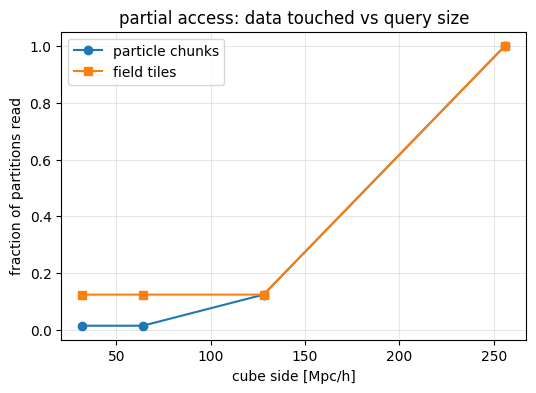

cone read pixels: {'pixels_total': 48, 'pixels_read': 7}
AMR read: {'nodes_total': 76015, 'nodes_read': 2270}  base subgrid (20, 20, 20)


In [5]:
s = SimStore(store)
sizes = [32, 64, 128, 256]
frac_chunks, frac_tiles = [], []
for L in sizes:
    s.read_box('snapshots', 0.0, Cube(0,L,0,L,0,L))
    st = s.last_read_stats; frac_chunks.append(st['chunks_read']/st['chunks_total'])
    s.read_field_box(0.0, Cube(0,L,0,L,0,L))
    st = s.last_read_stats; frac_tiles.append(st['tiles_read']/st['tiles_total'])
plt.figure(figsize=(6,4))
plt.plot(sizes, frac_chunks, 'o-', label='particle chunks')
plt.plot(sizes, frac_tiles, 's-', label='field tiles')
plt.xlabel('cube side [Mpc/h]'); plt.ylabel('fraction of partitions read')
plt.title('partial access: data touched vs query size'); plt.legend(); plt.grid(alpha=.3); plt.show()
cone = s.read_cone(Cone(lon=30, lat=10, radius_deg=25))
print('cone read pixels:', s.last_read_stats)
base, refined = s.read_amr_box(0.0, Cube(0,80,0,80,0,80))
print('AMR read:', s.last_read_stats, ' base subgrid', base.shape)

## 4. Read/write optimisation
Column projection reads fewer bytes; Morton row-order tightens parquet row-group bounding boxes for predicate pushdown.

In [6]:
from oneuniverse.simulation.oufsim.bench import measure_read
full = measure_read(lambda: s.read_box('snapshots', 0.0, Cube(0,120,0,120,0,120)))
proj = measure_read(lambda: s.read_box('snapshots', 0.0, Cube(0,120,0,120,0,120), columns=['x']))
print(f'peak bytes  full(6 cols)={full.peak_bytes/1e6:.1f} MB   projected(x)={proj.peak_bytes/1e6:.1f} MB')

peak bytes  full(6 cols)=2.5 MB   projected(x)=1.3 MB


## ⚠️ What is NOT working / current limitations (storage side)

1. **Re-encode, not wrap.** The store *re-encodes* the native arrays into parquet/tiles, so `store_size > native_size`. The architecture's petabyte-scale ideal is to *wrap* native files + write only the sidecar index (`projection='reference'`, not yet implemented). Fine for the dummy, wrong at TB scale.
2. **DM / linear generation only.** Storage supports hydro/phase-space/GR product *kinds*, but the only thing that *generates* them is the linear+PM dummy (dark matter). Multi-physics generation needs real codes.

In [7]:
native_mb = sum(f.stat().st_size for f in Path(native).rglob('*') if f.is_file())/1e6
store_mb = sum(f.stat().st_size for f in Path(store).rglob('*') if f.is_file())/1e6
print(f'native {native_mb:.1f} MB  ->  store {store_mb:.1f} MB   '
      f'(re-encode overhead {100*(store_mb/native_mb-1):+.0f}% ; '
      'a real backend should WRAP, not re-encode)')

native 75.8 MB  ->  store 83.2 MB   (re-encode overhead +10% ; a real backend should WRAP, not re-encode)
